# Data Exploration

## Input and target variables

**X** contains columns 1–30: chemical composition, welding parameters, and post-weld heat treatment. **Y** contains the measured properties in columns 31–38; columns 39–43 describe microstructure and can be considered additional targets. We exclude **Weld ID** (column 44), since it is only an identifier. The dataset has no "good/bad" label, so classification would require quality thresholds defined by an applicable standard or project requirements.

In [4]:
import matplotlib.pyplot as plt
from pathlib import Path
import json
import pandas as pd

In [ ]:
# Téléchargement automatique du jeu de données
# Ne fait rien si data/welddb/welddb.data existe déjà.
import tarfile
import urllib.request

WELDDB_URL = "https://www.phase-trans.msm.cam.ac.uk/map/data/tar/welddb.tar"
WELDDB_PATH = Path("data/welddb")


def fetch_welddb(url=WELDDB_URL, path=WELDDB_PATH):
    if (path / "welddb.data").exists():
        return
    path.mkdir(parents=True, exist_ok=True)
    tar_path = path / "welddb.tar"
    urllib.request.urlretrieve(url, tar_path)
    with tarfile.open(tar_path) as tar:
        for member in tar.getmembers():
            nom = Path(member.name).name
            if member.isfile() and nom.startswith("welddb."):
                (path / nom).write_bytes(tar.extractfile(member).read())
    tar_path.unlink()
    if not (path / "welddb.data").exists():
        raise FileNotFoundError("welddb.data introuvable dans l'archive")


fetch_welddb()

In [6]:
# N est le code utilisé dans le fichier pour signaler une valeur non renseignée.
colonnes = json.loads(Path("context/columns.json").read_text(encoding="utf-8"))
noms_colonnes = [
    f"{numero}. {infos['label']}"
    for numero, infos in sorted(colonnes.items(), key=lambda element: int(element[0]))
]

df = pd.read_csv(
    Path("data/welddb/welddb.data"),
    sep=r"\s+",
    header=None,
    names=noms_colonnes,
    na_values=["N"],
)

print(f"Dimensions de la base : {df.shape[0]} lignes et {df.shape[1]} colonnes")
display(df.head())

# Lignes identiques sur toutes les colonnes
lignes_dupliquees = df[df.duplicated(keep=False)]
print(f"Nombre de lignes dupliquées : {df.duplicated().sum()}")
display(lignes_dupliquees)

# Valeurs manquantes par colonne et colonnes complètement vides
valeurs_manquantes = df.isna().sum().sort_values(ascending=False)
print("Valeurs manquantes par colonne :")
display(valeurs_manquantes[valeurs_manquantes > 0])

colonnes_vides = df.columns[df.isna().all()].tolist()
print("Colonnes complètement vides :", colonnes_vides)


Dimensions de la base : 1652 lignes et 44 colonnes


,1. Carbon concentration,2. Silicon concentration,3. Manganese concentration,4. Sulphur concentration,5. Phosphorus concentration,6. Nickel concentration,7. Chromium concentration,8. Molybdenum concentration,9. Vanadium concentration,10. Copper concentration,...,35. Charpy temperature,36. Charpy impact toughness,37. Hardness,38. 50% FATT,39. Primary ferrite in microstructure,40. Ferrite with second phase,41. Acicular ferrite,42. Martensite,43. Ferrite with carbide aggregate,44. Weld ID
0,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aaw
1,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-28.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aawch
2,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-38.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aht
3,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Baw
4,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,-48.0,100.0,NaN,NaN,32,28.0,40.0,0.0,0.0,Evans-Ni/CMn-1990/1991-0Bawch


Nombre de lignes dupliquées : 0


,1. Carbon concentration,2. Silicon concentration,3. Manganese concentration,4. Sulphur concentration,5. Phosphorus concentration,6. Nickel concentration,7. Chromium concentration,8. Molybdenum concentration,9. Vanadium concentration,10. Copper concentration,...,35. Charpy temperature,36. Charpy impact toughness,37. Hardness,38. 50% FATT,39. Primary ferrite in microstructure,40. Ferrite with second phase,41. Acicular ferrite,42. Martensite,43. Ferrite with carbide aggregate,44. Weld ID


Valeurs manquantes par colonne :


38. 50% FATT                                1621
12. Tungsten concentration                  1577
43. Ferrite with carbide aggregate          1563
42. Martensite                              1563
40. Ferrite with second phase               1562
41. Acicular ferrite                        1562
39. Primary ferrite in microstructure       1554
11. Cobalt concentration                    1523
37. Hardness                                1514
20. Arsenic concentration                   1418
21. Antimony concentration                  1392
19. Tin concentration                       1356
17. Boron concentration                     1148
10. Copper concentration                    1074
6. Nickel concentration                      955
33. Elongation                               952
34. Reduction of Area                        947
32. Ultimate tensile strength                914
18. Niobium concentration                    900
31. Yield strength                           872
7. Chromium concentr

Colonnes complètement vides : []


The columns 38-42-43-40-41-39 are at least empty for 3 quarters of the instances. It is too empty to use as a training dataset, so we choose to not predict those characteristics and ignore the columns.
For the features, we also have 7 columns at least half empty (12-11-20-21-19-17-10) so we also choose to drop them as features.

Note: Ni (57.8 %), Nb (54.5 %), Cr (52.5 %) and Mo (52.0 %) are also above 50 % missing (they appear in the threshold table below) but are **kept**: they are the main alloying elements driving strength and toughness of the weld metal, and their missingness is handled at modelling time by imputation + a "was missing" indicator (step 6).


Input columns excluded for >= 50% missing values:


,feature,missing_percent_in_schema
column,,
6,Nickel concentration,57.81
7,Chromium concentration,52.54
8,Molybdenum concentration,52.00
10,Copper concentration,65.01
11,Cobalt concentration,92.19
12,Tungsten concentration,95.46
17,Boron concentration,69.49
18,Niobium concentration,54.48
19,Tin concentration,82.08


Potential numeric outliers (IQR rule; for review only):


,outlier_count,outlier_percent_of_numeric_values,lower_bound,upper_bound,feature,unit
27. Interpass temperature,550,34.08,200.000000,200.000000,Interpass temperature,°C
22. Current,310,22.08,-25.000000,495.000000,Current,A
15. Nitrogen concentration,166,14.03,20.250000,158.250000,Nitrogen concentration,ppmw
26. Heat input,161,9.75,-0.500000,3.500000,Heat input,kJ/mm
13. Oxygen concentration,156,12.42,218.500000,622.500000,Oxygen concentration,ppmw
2. Silicon concentration,153,9.26,0.135000,0.495000,Silicon concentration,wt%
4. Sulphur concentration,126,7.68,0.000000,0.016000,Sulphur concentration,wt%
23. Voltage,83,5.91,7.500000,43.500000,Voltage,V
5. Phosphorus concentration,76,4.63,-0.003500,0.024500,Phosphorus concentration,wt%
14. Titanium concentration,66,7.63,-90.000000,230.000000,Titanium concentration,ppmw


Non-numeric tokens in numeric inputs (check schema notes before parsing):


,feature,count,examples_in_data,documented_tokens,schema_note
column,,,,,
4,Sulphur concentration,7,[<0.002],[<0.002],One left-censored token '<0.002'; parse as bel...
9,Vanadium concentration,308,"[<0.0005, <0.01, <0.005, <5]","[<0.0005, <0.005, <0.01, <5]",'<5' is a unit-ambiguous detection-limit token...
14,Titanium concentration,70,"[<5, <100, <0.01, <10]","[<0.01, <5, <10, <100]",Mix of plain ppmw values and '<' detection-lim...
15,Nitrogen concentration,59,"[67tot33res, 66totndres, 61tot34res, 54totndre...","[48tot18res, 50tot17res, 52tot18res, 54tot24re...",59 rows use 'NNtotMMres' encoding (total vs re...
16,Aluminium concentration,403,"[<5, <50, <100, <0.01]","[<0.01, <5, <50, <100]",
27,Interpass temperature,38,[150-200],[],"'150-200' (38 rows) is a range token, not a si..."


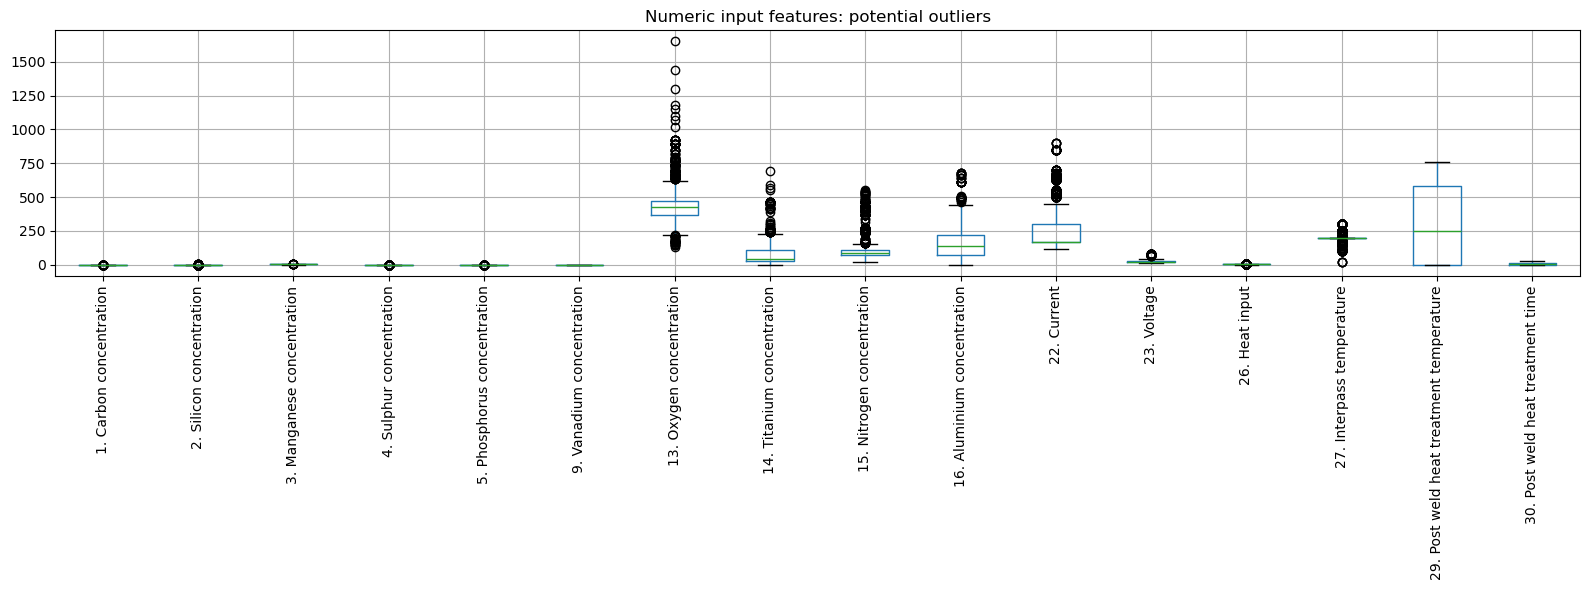

Feature scales before scaling (no scaling applied):


,feature,unit,schema_missing_percent,schema_min,schema_max,data_min,data_max,data_range,data_std,schema_note
column,,,,,,,,,,
13,Oxygen concentration,ppmw,23.97,132.000,1650.00,132.000,1650.00,1518.000,147.483825,
22,Current,A,15.01,115.000,900.00,115.000,900.00,785.000,192.560955,Missing jointly with Voltage (same 248 rows); ...
29,Post weld heat treatment temperature,°C,0.79,0.000,760.00,0.000,760.00,760.000,285.498003,0.0 in 610 rows (as-welded); otherwise common ...
14,Titanium concentration,ppmw,43.40,0.000,690.00,0.000,690.00,690.000,100.110707,Mix of plain ppmw values and '<' detection-lim...
16,Aluminium concentration,ppmw,45.22,0.004,680.00,0.004,680.00,679.996,155.781121,
15,Nitrogen concentration,ppmw,24.82,21.000,552.00,21.000,552.00,531.000,95.902889,59 rows use 'NNtotMMres' encoding (total vs re...
27,Interpass temperature,°C,0.00,20.000,300.00,20.000,300.00,280.000,39.550604,"'150-200' (38 rows) is a range token, not a si..."
23,Voltage,V,15.01,11.500,75.36,11.500,75.36,63.860,12.555629,
30,Post weld heat treatment time,hours,0.79,0.000,24.00,0.000,24.00,24.000,6.096034,0.0 in 610 rows (as-welded); pairs with col 29...


\n24. AC or DC (Welding parameter, current type: AC or DC)
Missing values: 215 (schema: 13.01%)
Rare categories (< 16 rows):


,count_in_data,count_in_schema


Category counts: data compared with columns.json


...

Schema note: Cross-check in data: '0' occurs only with AC (38 rows); '+' occurs with DC (1388) + a few AC (4); '-' only with DC (7). Jointly missing with col 24 on 156 rows.
\n28. Type of weld (Welding process: ShMA = MMA = manual metal arc; SA = SMA = submerged arc; FCA = flux cored arc; GTAA = gas tungsten arc automatic; GMAA = gas metal arc automatic; SAW-NG = submerged arc narrow gap; GMA-NG = gas metal arc narrow gap; ES = electroslag; TSA = tandem submerged arc)
Missing values: 0 (schema: 0.0%)
Rare categories (< 16 rows):


,count_in_data,count_in_schema
NGGMA,7,7
SAA,4,4
GTAA,4,4
GMAA,4,4


Category counts: data compared with columns.json


,count_in_data,count_in_schema
MMA,1140,1140
SA,261,261
FCA,87,87
TSA,87,87
ShMA,40,40
NGSAW,18,18
NGGMA,7,7
SAA,4,4
GTAA,4,4
GMAA,4,4


Schema note: File codes differ slightly from doc: SAW-NG appears as NGSAW, GMA-NG as NGGMA; SAA (4 rows) is an undocumented variant of SA; ShMA and MMA both mean manual metal arc (keep separate or merge as modelling choice). ES listed in doc but absent from data. Heavily imbalanced toward MMA.


In [3]:
# Use the schema in columns.json to select documented input features.
seuil_manquants = 50
metadonnees_entrees = {
    int(numero): infos
    for numero, infos in colonnes.items()
    if infos["role"] == "input"
}
colonnes_exclues = {
    numero: infos
    for numero, infos in metadonnees_entrees.items()
    if infos["missing"]["pct"] >= seuil_manquants
}

print(f"Input columns excluded for >= {seuil_manquants}% missing values:")
display(pd.DataFrame([
    {
        "column": numero,
        "feature": infos["label"],
        "missing_percent_in_schema": infos["missing"]["pct"],
    }
    for numero, infos in colonnes_exclues.items()
]).set_index("column"))

# Inspect remaining inputs only; the original DataFrame is not modified.
colonnes_a_examiner = {
    numero: infos
    for numero, infos in metadonnees_entrees.items()
    if numero not in colonnes_exclues
}
X_a_examiner = df[[f"{numero}. {infos['label']}" for numero, infos in colonnes_a_examiner.items()]].copy()
colonnes_categorielles = [
    f"{numero}. {infos['label']}"
    for numero, infos in colonnes_a_examiner.items()
    if infos["type"] == "categorical"
]
colonnes_numeriques = [
    f"{numero}. {infos['label']}"
    for numero, infos in colonnes_a_examiner.items()
    if infos["type"].startswith("continuous")
]

# Parse what is plainly numeric. Special encodings stay visible in the token report.
numerique = X_a_examiner[colonnes_numeriques].apply(pd.to_numeric, errors="coerce")

# 1. Flag potential outliers with the IQR rule; do not remove or cap them.
q1 = numerique.quantile(0.25)
q3 = numerique.quantile(0.75)
iqr = q3 - q1
borne_basse = q1 - 1.5 * iqr
borne_haute = q3 + 1.5 * iqr
masque_outliers = numerique.lt(borne_basse) | numerique.gt(borne_haute)

resume_outliers = pd.DataFrame({
    "feature": [colonnes[str(numero)]["label"] for numero in range(1, 1)],
})
resume_outliers = pd.DataFrame({
    "outlier_count": masque_outliers.sum(),
    "outlier_percent_of_numeric_values": (
        masque_outliers.sum() / numerique.notna().sum() * 100
    ).round(2),
    "lower_bound": borne_basse,
    "upper_bound": borne_haute,
})
resume_outliers["feature"] = [
    colonnes_a_examiner[int(name.split(".", 1)[0])]["label"]
    for name in resume_outliers.index
]
resume_outliers["unit"] = [
    colonnes_a_examiner[int(name.split(".", 1)[0])]["unit"]
    for name in resume_outliers.index
]
print("Potential numeric outliers (IQR rule; for review only):")
display(
    resume_outliers[resume_outliers["outlier_count"] > 0]
    .sort_values("outlier_count", ascending=False)
)

# Show tokens that could not be parsed and the schema notes explaining their format.
token_rows = []
for column in colonnes_numeriques:
    invalid = X_a_examiner[column].notna() & numerique[column].isna()
    if invalid.any():
        numero = int(column.split(".", 1)[0])
        infos = colonnes_a_examiner[numero]
        token_rows.append({
            "column": numero,
            "feature": infos["label"],
            "count": int(invalid.sum()),
            "examples_in_data": X_a_examiner.loc[invalid, column].astype(str).unique()[:8].tolist(),
            "documented_tokens": infos["observed"].get("censored_tokens", infos["observed"].get("non_numeric_tokens", [])),
            "schema_note": infos["observed"].get("note", ""),
        })
print("Non-numeric tokens in numeric inputs (check schema notes before parsing):")
display(pd.DataFrame(token_rows).set_index("column") if token_rows else pd.DataFrame())

# Boxplots help inspect the numeric ranges; they do not change any values.
plt.figure(figsize=(16, 6))
numerique.boxplot(rot=90)
plt.title("Numeric input features: potential outliers")
plt.tight_layout()
plt.show()

# 2. Compare measured ranges with the units and ranges documented in the schema.
echelle_rows = []
for column in colonnes_numeriques:
    numero = int(column.split(".", 1)[0])
    infos = colonnes_a_examiner[numero]
    observed = infos["observed"]
    echelle_rows.append({
        "column": numero,
        "feature": infos["label"],
        "unit": infos["unit"],
        "schema_missing_percent": infos["missing"]["pct"],
        "schema_min": observed.get("min", observed.get("numeric_range", {}).get("min")),
        "schema_max": observed.get("max", observed.get("numeric_range", {}).get("max")),
        "data_min": numerique[column].min(),
        "data_max": numerique[column].max(),
        "data_range": numerique[column].max() - numerique[column].min(),
        "data_std": numerique[column].std(),
        "schema_note": observed.get("note", ""),
    })
resume_echelles = pd.DataFrame(echelle_rows).set_index("column").sort_values(
    "data_range", ascending=False
)
print("Feature scales before scaling (no scaling applied):")
display(resume_echelles)

# 3. Compare observed categories with categories documented in columns.json.
for column in colonnes_categorielles:
    numero = int(column.split(".", 1)[0])
    infos = colonnes_a_examiner[numero]
    frequences = X_a_examiner[column].value_counts(dropna=False)
    categories_documentees = infos["observed"].get("categories", {})
    comparaison = pd.DataFrame({
        "count_in_data": frequences,
        "count_in_schema": pd.Series(categories_documentees),
    }).fillna(0).astype(int)
    rare_limit = max(5, int(0.01 * len(X_a_examiner)))
    print(f"\\n{numero}. {infos['label']} ({infos['details']})")
    print(f"Missing values: {X_a_examiner[column].isna().sum()} (schema: {infos['missing']['pct']}%)")
    print(f"Rare categories (< {rare_limit} rows):")
    display(comparaison[comparaison["count_in_data"] < rare_limit])
    print("Category counts: data compared with columns.json")
    display(comparaison)
    if infos["observed"].get("note"):
        print("Schema note:", infos["observed"]["note"])


## Analyses complémentaires

Ces cellules calculent les chiffres de la partie Exploration du rapport
(`report/sections/02_donnees.tex`) qui ne sont pas produits ailleurs.
Elles ne modifient pas les données.

### Valeurs manquantes des entrées : MCAR, MAR ou MNAR ?

Si les valeurs manquaient complètement au hasard (MCAR), les lignes avec et sans
nickel se ressembleraient. On regarde (1) si l'absence du nickel dépend de l'article
d'origine et (2) si les deux groupes de lignes diffèrent.

In [4]:
import sys
sys.path.insert(0, "preprocessing")
from ml_dataset import weld_source

article = df["44. Weld ID"].map(weld_source)
nickel_manquant = df["6. Nickel concentration"].isna()

# Part de lignes sans nickel dans chaque article
part_par_article = nickel_manquant.groupby(article).mean()
print(f"{article.nunique()} articles :")
print(f"  nickel toujours donné   : {(part_par_article == 0).sum()}")
print(f"  nickel jamais donné     : {(part_par_article == 1).sum()}")
print(f"  nickel donné en partie  : {((part_par_article > 0) & (part_par_article < 1)).sum()}")

# Si les valeurs manquaient au hasard (MCAR), les deux groupes se ressembleraient
procede = df["28. Type of weld"].replace({"ShMA": "MMA"})  # ShMA = MMA, même procédé
brut = (df["29. Post weld heat treatment temperature"] == 0) & (df["30. Post weld heat treatment time"] == 0)
comparaison = pd.DataFrame({
    "lignes": nickel_manquant.value_counts(),
    "soudage manuel MMA (%)": (procede == "MMA").groupby(nickel_manquant).mean() * 100,
    "brutes de soudage (%)": brut.groupby(nickel_manquant).mean() * 100,
    "limite d'élasticité moyenne (MPa)": df["31. Yield strength"].groupby(nickel_manquant).mean(),
}).rename(index={True: "nickel manquant", False: "nickel donné"}).rename_axis(None).round(0)
display(comparaison)

46 articles :
  nickel toujours donné   : 24
  nickel jamais donné     : 21
  nickel donné en partie  : 1


,lignes,soudage manuel MMA (%),brutes de soudage (%),limite d'élasticité moyenne (MPa)
nickel donné,697,49.0,21.0,531.0
nickel manquant,955,88.0,48.0,486.0


### Lignes complètes

Aucune ligne n'a toutes ses colonnes renseignées, ni même toutes ses entrées :
on ne peut pas se contenter de supprimer les lignes incomplètes.

In [5]:
entrees = df.columns[:30]
print("Lignes complètes sur les 44 colonnes :", df.notna().all(axis=1).sum())
print("Lignes avec les 30 entrées renseignées :", df[entrees].notna().all(axis=1).sum())

Lignes complètes sur les 44 colonnes : 0
Lignes avec les 30 entrées renseignées : 0


### Une ligne correspond à un essai, pas à une soudure

Plusieurs éprouvettes sont découpées dans un même cordon (traction, Charpy à
plusieurs températures, avec ou sans traitement thermique). On compte les cordons
distincts, c'est-à-dire les combinaisons distinctes de composition et de soudage.

In [6]:
cordons = df[df.columns[:28]].drop_duplicates()
etats = df[df.columns[:30]].drop_duplicates()
print(f"{len(df)} lignes")
print(f"  {len(cordons)} combinaisons distinctes de composition et de soudage (col. 1-28)")
print(f"  {len(etats)} en comptant aussi le traitement thermique (col. 1-30)")

# Exemple : un même cordon, une ligne de traction et quatre essais Charpy
display(df.loc[df["44. Weld ID"] == "Pat-1981-WB3/BX200",
               ["44. Weld ID", "29. Post weld heat treatment temperature",
                "31. Yield strength", "35. Charpy temperature", "36. Charpy impact toughness"]])

1652 lignes
  624 combinaisons distinctes de composition et de soudage (col. 1-28)
  1001 en comptant aussi le traitement thermique (col. 1-30)


,44. Weld ID,29. Post weld heat treatment temperature,31. Yield strength,35. Charpy temperature,36. Charpy impact toughness
960,Pat-1981-WB3/BX200,0.0,391.0,NaN,NaN
961,Pat-1981-WB3/BX200,0.0,NaN,-60.0,39.0
962,Pat-1981-WB3/BX200,0.0,NaN,-50.0,43.0
963,Pat-1981-WB3/BX200,0.0,NaN,-20.0,95.0
964,Pat-1981-WB3/BX200,0.0,NaN,0.0,114.0


### Traitement à 250 °C / 14 h

Ce traitement à basse température est sans doute un dégazage de l'hydrogène des
éprouvettes de traction, et non un vrai traitement thermique. Pour savoir s'il
modifie les propriétés, il faudrait un même cordon testé en traction brut **et**
après 250 °C / 14 h.

In [7]:
import numpy as np

t, h = df["29. Post weld heat treatment temperature"], df["30. Post weld heat treatment time"]
degazage = (t == 250) & (h == 14)
traction = df["31. Yield strength"].notna()
charpy = df["36. Charpy impact toughness"].notna()
print(f"Lignes à 250 °C / 14 h : {degazage.sum()} (traction : {(degazage & traction).sum()}, "
      f"Charpy : {(degazage & charpy).sum()})")

# Peut-on mesurer son effet ? Il faudrait un même cordon testé en traction à 0/0 ET à 250/14
etat = pd.Series(np.select([brut, degazage], ["brut", "250/14"], "autre"), index=df.index)
paires = etat[traction].groupby([df.loc[traction, c] for c in df.columns[:28]], dropna=False).agg(set)
print("Cordons testés en traction à la fois bruts et à 250 °C / 14 h :",
      paires.map(lambda e: {"brut", "250/14"} <= e).sum())

Lignes à 250 °C / 14 h : 333 (traction : 229, Charpy : 104)
Cordons testés en traction à la fois bruts et à 250 °C / 14 h : 0


### Énergies Charpy à valeurs fixes

Beaucoup d'énergies Charpy valent exactement 100 J ou 28 J. Ce sont probablement
des températures auxquelles la soudure atteint ces énergies, et non des énergies
mesurées : à vérifier dans les articles d'Evans.

In [8]:
energie = df["36. Charpy impact toughness"]
print("Valeurs les plus fréquentes de l'énergie Charpy :")
display(energie.value_counts().head(5).rename("lignes").to_frame())
print(f"Exactement 100 J : {(energie == 100).sum()} lignes ; exactement 28 J : {(energie == 28).sum()}")
print("Articles concernés (100 J ou 28 J) :")
display(article[energie.isin([100, 28])].value_counts().rename("lignes").to_frame().head(10))

Valeurs les plus fréquentes de l'énergie Charpy :


,lignes
36. Charpy impact toughness,
100.0,356
28.0,118
50.0,16
70.0,12
35.0,12


Exactement 100 J : 356 lignes ; exactement 28 J : 118
Articles concernés (100 J ou 28 J) :


,lignes
44. Weld ID,
EvansLetter,104
Evans-AlTi-1994,60
Evans-Ti/Mn-1992,40
Evans-Nb/Mn-1991,40
Evans-V/Mn-1991,39
Evans-Al/CMn-1990,35
Evans-Cr/CMn-1989,31
Evans-Ni/CMn-1990/1991,30
Evans-Ti/CMn-1992,20


## Preprocessing step 1 — left-censored `<...` values

In the raw file, a token such as `<0.002` means the element was **below the
detection limit 0.002** (left-censored), not zero and not missing — see the
`censored_tokens` entries in `context/columns.json`. Pandas parses these as
strings, so they must be resolved before any numeric modelling.

**Rule applied** (`preprocessing/decensor.py`): every `<x` token is replaced
by the numeric value `x`, e.g. `<0.002` → `0.002`. This is an **upper-bound
choice** (the true value lies in `[0, x]`); the classic alternative is the
half-limit `x/2`, or a censored-data model. Revisit if rows at detection
limits turn out to drive a model.

**Scope**: the 14 numerical columns whose schema documents censored tokens
(cols 4, 8–12, 14, 16–21, plus col 39 primary ferrite `<1`, which is an output
column). Everything else is out of scope here: `N` stays missing (empty field
in the output), and the other encodings need their own steps (col 15
`NNtotMMres`, col 27 `150-200` range, col 37 hardness `Hv` suffixes).

**Output**: `data/intermediate/decensored.csv` — one row per weld (1652 rows)
with the `weld_id` identifier (column 44) and the converted values of the 14
concerned columns (`colNN_Label` headers). Plain numerics pass through
unchanged; the raw file is never modified.

**Caveats to keep in mind**

- Replaced values pile up exactly at the limits (e.g. 343 Al rows become 5.0,
  395 B rows become 5.0, 266 V rows become 0.0005): expect artificial spikes
  in those distributions.
- Vanadium `<5` (9 `EvansLetter…Mo` rows) is **fixed as 5 ppmw = 0.0005 wt%**
  (`UNIT_FIX` in the script): on the same rows Ti, Al, B and Nb are all `<5`
  ppmw, and V is otherwise at most 0.32 wt% — `5.0` wt% would be absurd.
- Titanium and aluminium `<0.01` (16 `PantK-1990` rows each) are **fixed as
  0.01 wt% = 100 ppmw**: these columns are in ppmw, a 0.01 ppmw detection limit is
  unrealistic, and Nb on the same rows is 200–900 ppmw.
- `decensored.csv` is git-ignored intermediate data (see `.gitignore`); only the
  folder structure is tracked. Re-run the cell below to regenerate it.

In [9]:
import csv
import sys
sys.path.insert(0, "preprocessing")
from decensor import main

# Applies '<x' -> x and writes data/intermediate/decensored.csv
counts = main()

# Round-trip check: 1652 data rows, no '<' token left in value columns
rows = list(csv.reader(open("data/intermediate/decensored.csv", encoding="utf-8")))
assert len(rows) == 1653
assert all(not c.startswith("<") for r in rows[1:] for c in r[1:])
print("check: 1652 data rows, no '<' token left, header:", rows[0][:4], "...")

Concerned columns (14): 4, 8, 9, 10, 11, 12, 14, 16, 17, 18, 19, 20, 21, 39
Replacements '<x' -> x per column: col04=7, col08=2, col09=308, col10=14, col11=21, col12=12, col14=70, col16=403, col17=419, col18=299, col19=5, col20=8, col21=6, col39=2 (total 1576)
Wrote data/intermediate/decensored.csv: 1652 rows x 15 columns
Unit fix: col09 '<5' -> 0.0005 (limit given in another unit, see UNIT_FIX)
Unit fix: col14 '<0.01' -> 100.0 (limit given in another unit, see UNIT_FIX)
Unit fix: col16 '<0.01' -> 100.0 (limit given in another unit, see UNIT_FIX)
Examples (weld_id | column | raw -> new):
  Evans-Al/CMn-1990-<5aw | col09_Vanadium_concentration | <0.0005 -> 0.0005
  Evans-Al/CMn-1990-<5aw | col16_Aluminium_concentration | <5 -> 5.0
  Evans-Al/CMn-1990-<5aw | col17_Boron_concentration | <5 -> 5.0
  Evans-Al/CMn-1990-<5aw | col18_Niobium_concentration | <5 -> 5.0
  Evans-Al/CMn-1990-<5awch1 | col09_Vanadium_concentration | <0.0005 -> 0.0005
  Evans-Al/CMn-1990-<5awch1 | col16_Aluminium_con

## Preprocessing step 2 — nitrogen `NNtotMMres` encoding

59 rows report nitrogen (col 15) as e.g. `67tot33res`: **NN = total N**,
**MM = residual (filtered) N**, with `nd` when the residual was not
determined — see the schema note on col 15 in `context/columns.json`.

**Rule applied** (`preprocessing/nitrogen_total.py`): keep only the NN total
value, e.g. `67tot33res` → `67` (and `54totndres` → `54`). Total N is the
quantity comparable with the plain numeric reports, while the residual is only
available for a subset of rows. Alternative: split into two features
(total + residual) — revisit if a nitrogen effect shows up in modelling.

**Scope**: only col 15 matches this encoding (scan of all numerical columns).
Plain numerics pass through unchanged, `N` stays missing (empty field).

**Output**: `data/intermediate/nitrogen_total.csv` — one row per weld (1652
rows) with `weld_id` and the converted `col15_Nitrogen_concentration` values.
The raw file is never modified. Like `decensored.csv`, it is git-ignored
intermediate data; re-run the cell below to regenerate it.

**Caveat**: this assumes the plain numeric reports are also totals, consistent
with the column documentation (`ppmw`). The residual information is discarded.

In [10]:
import csv
import sys
sys.path.insert(0, "preprocessing")
from nitrogen_total import main

# Keeps NN from 'NNtotMMres' and writes data/intermediate/nitrogen_total.csv
counts = main()

# Round-trip check: 1652 data rows, no 'tot' token left
rows = list(csv.reader(open("data/intermediate/nitrogen_total.csv", encoding="utf-8")))
assert len(rows) == 1653
assert all("tot" not in c for r in rows[1:] for c in r[1:])
print("check: 1652 data rows, no 'tot' token left, header:", rows[0])

Concerned columns: [15] (tokens matching NNtotMMres)
Replacements NNtotMMres -> NN: 48tot18res-> 48 (x7), 50tot17res-> 50 (x7), 52tot18res-> 52 (x7), 54tot24res-> 54 (x7), 54totndres-> 54 (x6), 61tot34res-> 61 (x7), 66totndres-> 66 (x11), 67tot33res-> 67 (x7) (total 59)
Wrote data/intermediate/nitrogen_total.csv: 1652 rows x 2 columns
Examples (weld_id | raw -> new):
  Evans-Al/CMn-1990-<5aw | 67tot33res -> 67
  Evans-Al/CMn-1990-<5awch1 | 67tot33res -> 67
  Evans-Al/CMn-1990-<5awch2 | 67tot33res -> 67
  Evans-Al/CMn-1990-<5aw | 67tot33res -> 67
  Evans-Al/CMn-1990-<5ht | 67tot33res -> 67
  Evans-Al/CMn-1990-<5htch1 | 67tot33res -> 67
  Evans-Al/CMn-1990-<5htch2 | 67tot33res -> 67
  Evans-Al/CMn-1990-20aw | 66totndres -> 66
check: 1652 data rows, no 'tot' token left, header: ['weld_id', 'col15_Nitrogen_concentration']


## Preprocessing step 3 — interpass `xx-yy` range (col 27)

38 rows report the interpass temperature as the range `150-200` instead of a
single value — see the schema note on col 27 in `context/columns.json`.

**Rule applied** (`preprocessing/interpass_range.py`): replace every `xx-yy`
token with the mean of the range, i.e. `150-200` → `175.0`. The midpoint
treats the reported interval as centered on its middle; an alternative is
keeping an interval-valued feature, which most models cannot ingest directly.

**Scope**: only col 27 matches this encoding (scan of all numerical columns).
All 38 range rows come from a single source (`PantK-1990` welds) — a reporting
habit of that series, not scattered noise. Plain numerics pass through
unchanged; col 27 has no missing values.

**Output**: `data/intermediate/interpass_mean.csv` — one row per weld (1652
rows) with `weld_id` and the converted `col27_Interpass_temperature` values.
The raw file is never modified. Like the previous steps, it is git-ignored
intermediate data; re-run the cell below to regenerate it.

In [11]:
import csv
import sys
sys.path.insert(0, "preprocessing")
from interpass_range import main

# Replaces 'xx-yy' with the range mean and writes data/intermediate/interpass_mean.csv
counts = main()

# Round-trip check: 1652 data rows, no range token left in value columns
rows = list(csv.reader(open("data/intermediate/interpass_mean.csv", encoding="utf-8")))
assert len(rows) == 1653
assert all("-" not in c for r in rows[1:] for c in r[1:])
print("check: 1652 data rows, no range token left, header:", rows[0])

Concerned columns: [27] (tokens matching xx-yy)
Replacements xx-yy -> mean: 150-200 -> 175.0 (x38) (total 38)
Wrote data/intermediate/interpass_mean.csv: 1652 rows x 2 columns
Examples (weld_id | raw -> new):
  PantK-1990-w1 | 150-200 -> 175.0
  PantK-1990-w2 | 150-200 -> 175.0
  PantK-1990-w3 | 150-200 -> 175.0
  PantK-1990-w4.0 | 150-200 -> 175.0
  PantK-1990-w4.1 | 150-200 -> 175.0
  PantK-1990-w4.2 | 150-200 -> 175.0
  PantK-1990-w4.3 | 150-200 -> 175.0
  PantK-1990-w4.4 | 150-200 -> 175.0
check: 1652 data rows, no range token left, header: ['weld_id', 'col27_Interpass_temperature']


## Preprocessing step 4 — categorical columns (cols 24 and 28)

**Current type (col 24)** is missing on 215 rows, but the electrode polarity
(col 25) gives it: `+` / `-` only exist in DC, and `0` is the code for AC
(schema note on col 25). **Rule applied** (`preprocessing/categorical_clean.py`):
when col 24 is missing, `+`/`-` → `DC` and `0` → `AC`. This recovers 59 rows
(all `+` → DC); 156 rows miss both columns and stay missing (handled as their
own `missing` level in step 6). Reported values are never changed. 4 rows report
AC with polarity `+`: kept as reported.

**Weld process (col 28)** has synonyms and very rare codes. Merges:

| raw code(s) | rows | → level | reason |
|---|---|---|---|
| `ShMA` | 40 | `MMA` | same process (manual metal arc), documented synonym |
| `SAA`, `NGSAW` | 4 + 18 | `SA` | submerged arc variants (undocumented SA variant, narrow gap) |
| `GTAA`, `GMAA`, `NGGMA` | 4 + 4 + 7 | `GSA` | gas-shielded arc processes, too rare alone |

`TSA` (tandem submerged arc) and `FCA` (87 rows each) stay separate.
Result: 5 levels — MMA 1180, SA 283, FCA 87, TSA 87, GSA 15. Levels with 4
rows cannot be learnt and would mostly end up absent from a CV training fold.

**Output**: `data/intermediate/categorical.csv` (`weld_id`, `col24_AC_or_DC`,
`col28_Type_of_weld`), absorbed by the assembly step without code change.
Polarity (col 25) is left as reported (`+`, `-`, `0`, missing).

In [12]:
import csv
import sys
sys.path.insert(0, "preprocessing")
from categorical_clean import main

# Fills col 24 from polarity, groups col 28 and writes data/intermediate/categorical.csv
inferred, merged = main()

# Check: 1652 rows, only DC/AC/empty in col 24, only the 5 grouped levels in col 28
rows = list(csv.DictReader(open("data/intermediate/categorical.csv", encoding="utf-8")))
assert len(rows) == 1652
assert {r["col24_AC_or_DC"] for r in rows} == {"DC", "AC", ""}
assert {r["col28_Type_of_weld"] for r in rows} == {"MMA", "SA", "TSA", "FCA", "GSA"}
print("check: 1652 rows, col 24 in {DC, AC, missing}, col 28 in 5 levels")


col 24 filled from polarity: + -> DC (x59) (total 59); still missing: 156
col 28 merged: GMAA -> GSA (x4), GTAA -> GSA (x4), NGGMA -> GSA (x7), NGSAW -> SA (x18), SAA -> SA (x4), ShMA -> MMA (x40) (total 77)
col 28 levels: MMA=1180, SA=283, FCA=87, TSA=87, GSA=15
Wrote data/intermediate/categorical.csv: 1652 rows x 3 columns
check: 1652 rows, col 24 in {DC, AC, missing}, col 28 in 5 levels


## Preprocessing step 4b — unknown heat treatment (cols 29–30)

13 rows miss both the heat-treatment temperature and time. They are all
`Gar&K-1975-25mm-<n>ht` welds: the `ht` suffix means **heat-treated**, so the generic
median imputation of step 6 (250 °C, which is in fact the 250 °C / 14 h degassing
plateau) would describe them wrongly.

**Rule applied** (`preprocessing/heat_treatment.py`): the same article treats its other
welds (`Gar&K-1975-12mm-<n>ht`) at **600 °C for 0.75 h**; we assume the 25 mm welds
received the same treatment. This is an assumption (thicker plates may get a longer
treatment), listed in the report. Reported values are never changed.

Step 6 also adds two 0/1 inputs, `as_welded` (treatment `0/0`, 610 rows) and
`degassing_250C_14h` (333 rows): a temperature alone would put "as-welded", "degassing"
and a real tempering at 550–750 °C on one scale, while they are different kinds of state.

In [13]:
import csv
import sys
sys.path.insert(0, "preprocessing")
from heat_treatment import main

# Fills the 13 unknown treatments and writes data/intermediate/heat_treatment.csv
filled = main()

rows = list(csv.DictReader(open("data/intermediate/heat_treatment.csv", encoding="utf-8")))
assert len(rows) == 1652 and len(filled) == 13
assert all(r["col29_Post_weld_heat_treatment_temperature"] != "" for r in rows)
print("check: 1652 rows, no unknown heat treatment left")

Unknown treatment filled from the same article (600 degC, 0.75 h): 13 rows (Gar&K-1975-25mm-1ht ... Gar&K-1975-25mm-13ht); still missing: 0
Wrote data/intermediate/heat_treatment.csv: 1652 rows x 3 columns
check: 1652 rows, no unknown heat treatment left


## Preprocessing step 5 — assembly into `cleaned.csv`

The step scripts above each resolve one encoding into their own table in
`data/intermediate/`. `preprocessing/build_model_table.py` joins **every**
intermediate file into a single modeling table, generically: each file provides
`weld_id` plus `colNN_Label` columns, and any column 1–43 covered by no file
falls back to the raw value from `welddb.data` (`N` → empty field, categoricals
kept as-is). Adding a future step file is enough — the script absorbs it with
no code change, just re-run.

Safety checks (fail loudly instead of silently misaligning): rows are joined
positionally with identical `weld_id` order everywhere (IDs repeat across rows,
so no key-join), headers are validated against `context/columns.json`, and a
column covered by two files is an error.

**Excluded columns** (`DROPPED` in the script, per the decision at the top of
this notebook, plus col 37 hardness added later): sparse targets 37–43 and
half-empty inputs 10, 11, 12, 17, 19, 20, 21 — 14 columns. Intermediates still
compute them; exclusion happens here at assembly time.

**Output**: `data/cleaned/cleaned.csv` — 1652 rows × 30 columns (`weld_id` +
29 kept columns). Current provenance: cols 24 and 28 from `categorical.csv`,
6 columns from `decensored.csv` (4, 8, 9, 14, 16, 18), col 15 from
`nitrogen_total.csv`, col 27 from `interpass_mean.csv`, 19 from raw. Like `intermediate/`, `data/cleaned/` is
git-ignored data with only the folder tracked — re-run the cell below to
regenerate.

In [14]:
import csv
import re
import sys
sys.path.insert(0, "preprocessing")
from build_model_table import main as assemble

# Joins intermediate/ + raw fallback (minus DROPPED) into data/cleaned/cleaned.csv
assemble()

# Check: shape and no dropped column present
rows = list(csv.reader(open("data/cleaned/cleaned.csv", encoding="utf-8")))
dropped = {10, 11, 12, 17, 19, 20, 21, 37, 38, 39, 40, 41, 42, 43}
nums = [int(re.match(r"col(\d+)_", h).group(1)) for h in rows[0][1:]]
assert len(rows) == 1653 and not (set(nums) & dropped)
print("check: 1652 data rows x", len(rows[0]), "columns, none dropped present")

Intermediate files joined (5): categorical.csv, decensored.csv, heat_treatment.csv, interpass_mean.csv, nitrogen_total.csv
  categorical.csv: 2 columns [24, 28]
  decensored.csv: 6 columns [4, 8, 9, 14, 16, 18]
  heat_treatment.csv: 2 columns [29, 30]
  interpass_mean.csv: 1 columns [27]
  nitrogen_total.csv: 1 columns [15]
  raw: 17 columns [1, 2, 3, 5, 6, 7, 13, 22, 23, 25, 26, 31, 32, 33, 34, 35, 36]
Wrote data/cleaned/cleaned.csv: 1652 rows x 30 columns
Dropped per notebook decision (14): [10, 11, 12, 17, 19, 20, 21, 37, 38, 39, 40, 41, 42, 43]
check: 1652 data rows x 30 columns, none dropped present


## Preprocessing step 6 — modelling interface (targets, CV groups, imputation, scaling, encoding)

`cleaned.csv` is parsed but still has missing values and raw scales (from 10⁻⁴
wt% to 10³ ppm or °C). Imputation, scaling and one-hot encoding **learn
statistics** from the data (medians, means, standard deviations, categories):
fitting them on the whole file before cross-validation leaks test information
into training. They are therefore **not** applied to the CSV but returned as an
unfitted sklearn `ColumnTransformer` (`make_preprocessor` in
`preprocessing/ml_dataset.py`), to put first in every model `Pipeline` so it is
re-fitted on each training fold.

**Targets** — one model per target, trained on the rows reporting it (the
tensile rows and the Charpy rows of a weld are separate rows in the file, so a
single multi-output table would be mostly empty):

| key | target | rows |
|---|---|---|
| `yield` | col 31 yield strength (MPa) | 780 |
| `uts` | col 32 ultimate tensile strength (MPa) | 738 |
| `elongation` | col 33 elongation (%) | 700 |
| `roa` | col 34 reduction of area (%) | 705 |
| `charpy` | col 36 Charpy energy (J) | 879 |

**Inputs**: the 23 kept columns 1–30 (composition, welding parameters, PWHT).
For `charpy`, the test temperature (col 35) is added as input: the energy is
only meaningful at a given temperature. Other outputs are never used as inputs.

**Preprocessing (fitted per fold)**
- numeric: median imputation + one 0/1 "was missing" indicator per column with
  missing values, then standardisation. Missingness is structural (it depends
  on what each source paper reported), so the indicator keeps that information
  instead of pretending the median was measured. `impute='mean'` is available
  to compare.
- categorical (cols 24, 25, 28): missing → its own `missing` level, then
  one-hot; a level unseen in a training fold is ignored at test time.
- Outliers are **kept**: the review in `context/columns.json` showed they are
  deliberate experimental series (e.g. high S/P `Mart-` welds, 9Cr welds), not
  errors. Robust models / leverage checks are the place to handle them.

**CV groups** — `source`, the literature source parsed from the Weld ID
(`Evans-AlTi-1994-450/1ch1` → `Evans-AlTi-1994`, `p9-RR82011` → `RR82011`,
two spelling variants merged): 46 sources. Rows of one weld (as-welded, PWHT,
Charpy) and of one experimental series are near-duplicates; a random row split
would put them on both sides and overestimate performance. Use `GroupKFold`
(or `LeaveOneGroupOut`) with `groups=source`.

In [15]:
import sys
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
sys.path.insert(0, "preprocessing")
from ml_dataset import TARGETS, get_xy, load_cleaned, make_preprocessor

ml = load_cleaned()
print(f"{ml.shape[0]} rows, {ml['source'].nunique()} sources")
display(ml["source"].value_counts().rename("rows").to_frame().T)

summary = []
for target in TARGETS:
    X, y, groups = get_xy(ml, target)
    Xt = make_preprocessor(X).fit_transform(X)
    assert not np.isnan(Xt).any()
    # Leakage check: no source on both sides of any GroupKFold split
    for train, test in GroupKFold(n_splits=5).split(X, y, groups):
        assert not set(groups.iloc[train]) & set(groups.iloc[test])
    summary.append({
        "target": target, "column": TARGETS[target], "rows": len(y),
        "sources": groups.nunique(), "raw inputs": X.shape[1],
        "features after preprocessing": Xt.shape[1],
        "y mean": round(y.mean(), 1), "y std": round(y.std(), 1),
    })
display(pd.DataFrame(summary).set_index("target"))
print("check: no NaN after preprocessing, no source shared between train and test folds")

# Example of the transformed design matrix (fitted on all rows here for display only)
X, y, groups = get_xy(ml, "charpy")
prep = make_preprocessor(X).fit(X)
display(pd.DataFrame(prep.transform(X), columns=prep.get_feature_names_out(), index=X.index).head())


1652 rows, 46 sources


source,EvansLetter,Evans-AlTi-1994,Evans-StressRelief-1991,SvenGret-1990,Pat-1981,Mart,Gar&K-1975,Evans-V/Mn-1991,Evans-Nb/Mn-1991,Evans-Ti/Mn-1992,...,Kluket-CuMnB-1994,Birmingham,Evans-Mn-1977,SurianEtAl-C-1991,Alekseev&-CMnNi-1991,Natsume-1990,Sw&Rog-1973,RC81033,Kik,Inag&-1966
rows,156,114,110,96,79,70,66,60,60,60,...,12,9,8,8,7,4,4,4,2,2


,column,rows,sources,raw inputs,features after preprocessing,y mean,y std
target,,,,,,,
yield,col31_Yield_strength,780,42,25,47,508.6,92.9
uts,col32_Ultimate_tensile_strength,738,41,25,47,594.4,88.6
elongation,col33_Elongation,700,36,25,47,26.3,4.9
roa,col34_Reduction_of_Area,705,34,25,47,71.8,8.9
charpy,col36_Charpy_impact_toughness,879,26,26,45,87.7,50.1


check: no NaN after preprocessing, no source shared between train and test folds


,col01_Carbon_concentration,col02_Silicon_concentration,col03_Manganese_concentration,col04_Sulphur_concentration,col05_Phosphorus_concentration,col06_Nickel_concentration,col07_Chromium_concentration,col08_Molybdenum_concentration,col09_Vanadium_concentration,col13_Oxygen_concentration,...,col24_AC_or_DC_DC,col24_AC_or_DC_missing,col25_Electrode_polarity_+,col25_Electrode_polarity_0,col25_Electrode_polarity_missing,col28_Type_of_weld_FCA,col28_Type_of_weld_GSA,col28_Type_of_weld_MMA,col28_Type_of_weld_SA,col28_Type_of_weld_TSA
1,-1.599779,-0.168835,-1.388286,-0.114921,-0.035620,-0.528797,-0.007468,-0.115835,-0.26414,-0.098196,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-1.599779,-0.168835,-1.388286,-0.114921,-0.035620,-0.528797,-0.007468,-0.115835,-0.26414,-0.098196,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.599779,-0.062527,-0.439411,-0.187437,0.045599,-0.528797,-0.007468,-0.115835,-0.26414,-0.098196,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,-1.599779,-0.062527,-0.439411,-0.187437,0.045599,-0.528797,-0.007468,-0.115835,-0.26414,-0.098196,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,-1.297731,0.362704,0.559405,-0.187437,0.045599,-0.528797,-0.007468,-0.115835,-0.26414,-0.098196,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Analyse descriptive (figures du rapport)

Figures de la partie Exploration du rapport, enregistrées dans `report/figures/`.
Elles utilisent la base brute (`df`) pour les valeurs manquantes et la table nettoyée
(`ml`, valeurs décodées) pour le reste. Palette : bleu / orange / aqua de la palette de
référence (validée pour les daltoniens), fond clair pour l'impression.

In [16]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.decomposition import PCA

sys.path.insert(0, "preprocessing")
from ml_dataset import TARGETS, input_columns, load_cleaned, make_preprocessor

FIGURES = Path("report/figures")
FIGURES.mkdir(parents=True, exist_ok=True)
ENCRE, ENCRE_2, GRILLE = "#0b0b0b", "#52514e", "#e4e3df"
BLEU, ORANGE, AQUA, GRIS = "#2a78d6", "#eb6834", "#1baf7a", "#b5b3ad"
DIVERGENTE = LinearSegmentedColormap.from_list(
    "bleu_rouge", ["#104281", "#5598e7", "#f0efec", "#ec8a89", "#a32c2c"])
plt.rcParams.update({
    "font.size": 8, "axes.titlesize": 9, "axes.labelsize": 8,
    "axes.edgecolor": GRILLE, "axes.labelcolor": ENCRE_2, "axes.titlecolor": ENCRE,
    "xtick.color": ENCRE_2, "ytick.color": ENCRE_2, "text.color": ENCRE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRILLE, "grid.linewidth": 0.6,
    "legend.frameon": False, "savefig.bbox": "tight", "figure.dpi": 110,
})

ml = load_cleaned()
NOMS = {  # noms courts en français pour les figures
    "col01_Carbon_concentration": "C", "col02_Silicon_concentration": "Si",
    "col03_Manganese_concentration": "Mn", "col04_Sulphur_concentration": "S",
    "col05_Phosphorus_concentration": "P", "col06_Nickel_concentration": "Ni",
    "col07_Chromium_concentration": "Cr", "col08_Molybdenum_concentration": "Mo",
    "col09_Vanadium_concentration": "V", "col13_Oxygen_concentration": "O",
    "col14_Titanium_concentration": "Ti", "col15_Nitrogen_concentration": "N",
    "col16_Aluminium_concentration": "Al", "col18_Niobium_concentration": "Nb",
    "col22_Current": "Courant", "col23_Voltage": "Tension",
    "col26_Heat_input": "Énergie de soudage", "col27_Interpass_temperature": "T entre passes",
    "col29_Post_weld_heat_treatment_temperature": "T traitement",
    "col30_Post_weld_heat_treatment_time": "Durée traitement",
    "col31_Yield_strength": "Limite d'élasticité", "col32_Ultimate_tensile_strength": "Résistance",
    "col33_Elongation": "Allongement", "col34_Reduction_of_Area": "Striction",
    "col35_Charpy_temperature": "T essai Charpy", "col36_Charpy_impact_toughness": "Énergie Charpy",
}
numeriques = [c for c in input_columns(ml) if c in NOMS]

### Valeurs manquantes par entrée

Les entrées écartées (au moins à moitié vides et secondaires) sont en gris.

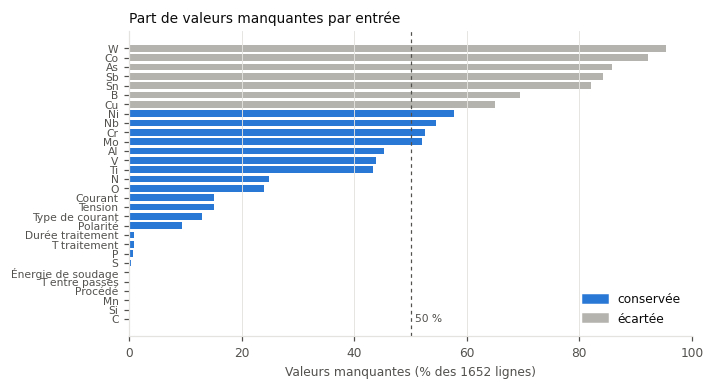

In [17]:
manquants = df[df.columns[:30]].isna().mean().mul(100).sort_values()
ecartees = {f"{n}." for n in (10, 11, 12, 17, 19, 20, 21)}
couleurs = [GRIS if nom.split(" ")[0] in ecartees else BLEU for nom in manquants.index]
fig, ax = plt.subplots(figsize=(6.6, 3.6))
ax.barh(range(len(manquants)), manquants.values, color=couleurs, height=0.7)
NOMS_ENTREES = {1: "C", 2: "Si", 3: "Mn", 4: "S", 5: "P", 6: "Ni", 7: "Cr", 8: "Mo", 9: "V",
                10: "Cu", 11: "Co", 12: "W", 13: "O", 14: "Ti", 15: "N", 16: "Al", 17: "B",
                18: "Nb", 19: "Sn", 20: "As", 21: "Sb", 22: "Courant", 23: "Tension",
                24: "Type de courant", 25: "Polarité", 26: "Énergie de soudage",
                27: "T entre passes", 28: "Procédé", 29: "T traitement", 30: "Durée traitement"}
ax.set_yticks(range(len(manquants)),
              [NOMS_ENTREES[int(n.split(".")[0])] for n in manquants.index], fontsize=7)
ax.set_xlabel("Valeurs manquantes (% des 1652 lignes)")
ax.set_xlim(0, 100); ax.grid(axis="y", visible=False)
ax.axvline(50, color=ENCRE_2, linewidth=0.8, linestyle=(0, (3, 3)))
ax.text(50.8, 0, "50 %", color=ENCRE_2, fontsize=7, va="center")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=BLEU), plt.Rectangle((0, 0), 1, 1, color=GRIS)],
          labels=["conservée", "écartée"], loc="lower right")
ax.set_title("Part de valeurs manquantes par entrée", loc="left")
fig.savefig(FIGURES / "manquants.pdf"); plt.show()

### Distribution des grandeurs à prédire

Les pics de l'énergie Charpy à 100 J et 28 J correspondent probablement à des
températures de transition (voir « Analyses complémentaires »).

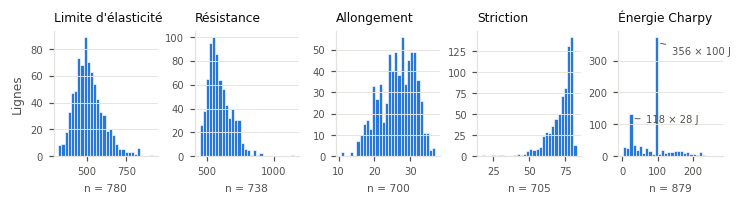

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(6.8, 1.9))
for ax, (cle, col) in zip(axes, TARGETS.items()):
    valeurs = ml[col].dropna()
    ax.hist(valeurs, bins=30, color=BLEU, edgecolor="white", linewidth=0.4)
    ax.set_title(NOMS[col], loc="left", fontsize=8)
    ax.set_xlabel(f"n = {len(valeurs)}", fontsize=7); ax.grid(axis="x", visible=False)
    ax.tick_params(labelsize=6.5)
axes[0].set_ylabel("Lignes")
pics = ml[TARGETS["charpy"]].value_counts()
for energie in (28, 100):
    axes[-1].annotate(f"{pics[energie]} × {energie} J", xy=(energie, pics[energie]),
                      xytext=(energie + 40, pics[energie] * 0.9), fontsize=6.5, color=ENCRE_2,
                      arrowprops=dict(arrowstyle="-", color=ENCRE_2, linewidth=0.6))
fig.tight_layout(w_pad=0.6)
fig.savefig(FIGURES / "cibles.pdf"); plt.show()

### Corrélations entre entrées et grandeurs à prédire

Corrélation de Spearman (sur les rangs : insensible aux valeurs extrêmes, capte les
relations monotones non linéaires), calculée sur les lignes où les deux variables sont
renseignées. Les valeurs |r| ≥ 0,4 sont écrites ; les paires avec moins de 30 lignes
communes ne sont pas affichées.

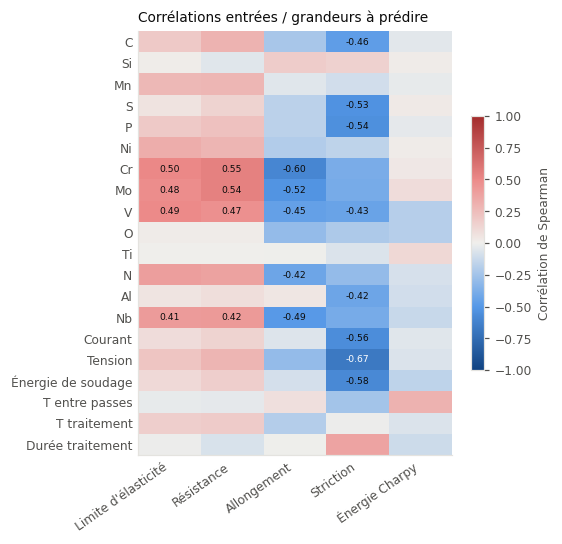

Corrélations les plus fortes (|r| >= 0.4) :


,,r
Tension,Striction,-0.67
Cr,Allongement,-0.60
Énergie de soudage,Striction,-0.58
Courant,Striction,-0.56
Cr,Résistance,0.55
Mo,Résistance,0.54
P,Striction,-0.54
S,Striction,-0.53
Mo,Allongement,-0.52
Cr,Limite d'élasticité,0.50


In [19]:
# Corrélation de Spearman (rangs : robuste aux valeurs extrêmes et aux relations non
# linéaires monotones), calculée sur les lignes où les deux variables sont renseignées.
sorties = list(TARGETS.values())
correlations = ml[numeriques + sorties].corr(method="spearman").loc[numeriques, sorties]
effectifs = ml[numeriques].notna().T.astype(int) @ ml[sorties].notna().astype(int)
correlations = correlations.where(effectifs >= 30)  # trop peu de lignes communes : non affiché
fig, ax = plt.subplots(figsize=(4.6, 5.0))
im = ax.imshow(correlations.values, cmap=DIVERGENTE, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(sorties)), [NOMS[c] for c in sorties], rotation=35, ha="right")
ax.set_yticks(range(len(numeriques)), [NOMS[c] for c in numeriques])
ax.grid(False); ax.tick_params(length=0)
for i in range(len(numeriques)):
    for j in range(len(sorties)):
        r = correlations.values[i, j]
        if np.isnan(r):
            ax.text(j, i, "–", ha="center", va="center", fontsize=6, color=ENCRE_2)
        elif abs(r) >= 0.4:
            ax.text(j, i, f"{r:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if abs(r) >= 0.6 else ENCRE)
fig.colorbar(im, ax=ax, shrink=0.6, label="Corrélation de Spearman")
ax.set_title("Corrélations entrées / grandeurs à prédire", loc="left")
fig.savefig(FIGURES / "correlations.pdf"); plt.show()
print("Corrélations les plus fortes (|r| >= 0.4) :")
display(correlations.stack().loc[lambda s: s.abs() >= 0.4].sort_values(key=abs, ascending=False)
        .rename(index=NOMS).round(2).to_frame("r"))

### ACP sur les entrées numériques

Une ligne par état de soudure (composition, soudage et traitement identiques), pour ne
pas compter plusieurs fois un métal testé à plusieurs températures. Valeurs manquantes
remplacées par la médiane puis standardisation, sans indicateurs de valeur manquante :
on décrit le métal, pas la façon dont il a été rapporté.

995 états de soudure, 20 variables numériques
Variance expliquée (%) : [20.5 17.4  8.8  7.9  6.4  5.3] | cumulée 2 axes : 37.9 | 5 axes : 61.0


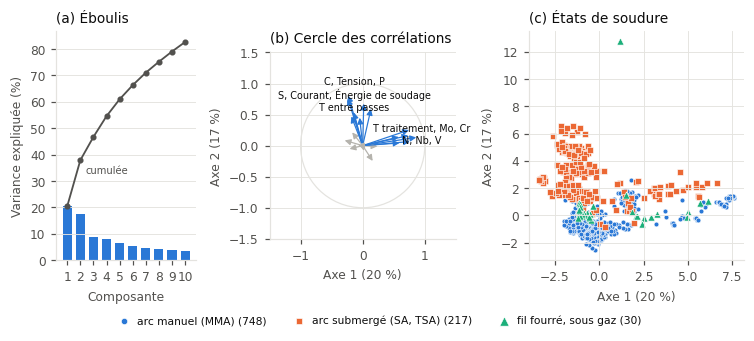

,axe 1,axe 2
Cr,0.91,0.14
Mo,0.81,0.07
V,0.79,0.27
N,0.78,0.17
T traitement,0.64,0.05
Nb,0.63,0.15
Mn,-0.34,0.10
O,0.29,-0.01


In [20]:
# Une ligne par état de soudure (composition + soudage + traitement) pour ne pas compter
# plusieurs fois un même métal testé à plusieurs températures ; valeurs manquantes
# complétées par la médiane puis standardisation (sans indicateurs : on veut décrire le
# métal, pas la façon dont il a été rapporté).
etats = ml.drop_duplicates(subset=input_columns(ml)).reset_index(drop=True)
X = etats[numeriques]
X_std = (X.fillna(X.median()) - X.fillna(X.median()).mean()) / X.fillna(X.median()).std()
acp = PCA().fit(X_std)
coords = acp.transform(X_std)
variance = acp.explained_variance_ratio_ * 100
print(f"{len(etats)} états de soudure, {len(numeriques)} variables numériques")
print("Variance expliquée (%) :", np.round(variance[:6], 1), "| cumulée 2 axes :",
      round(variance[:2].sum(), 1), "| 5 axes :", round(variance[:5].sum(), 1))

fig, axes = plt.subplots(1, 3, figsize=(6.9, 2.9), gridspec_kw={"width_ratios": [0.75, 1, 1.15]})
# (a) éboulis des valeurs propres
ax = axes[0]
ax.bar(range(1, 11), variance[:10], color=BLEU, width=0.7)
ax.plot(range(1, 11), np.cumsum(variance[:10]), color=ENCRE_2, linewidth=1.2, marker="o", markersize=3)
ax.set_xticks(range(1, 11)); ax.set_xlabel("Composante"); ax.set_ylabel("Variance expliquée (%)")
ax.set_title("(a) Éboulis", loc="left"); ax.grid(axis="x", visible=False)
ax.text(2.4, np.cumsum(variance[:10])[1] - 2, "cumulée", ha="left", va="top", fontsize=6.5, color=ENCRE_2)
# (b) cercle des corrélations
ax = axes[1]
charges = acp.components_[:2].T * np.sqrt(acp.explained_variance_[:2])
ax.add_patch(plt.Circle((0, 0), 1, fill=False, color=GRILLE, linewidth=0.8))
fortes = []
for (x, y), col in zip(charges, numeriques):
    fort = np.hypot(x, y) >= 0.5
    ax.annotate("", xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=BLEU if fort else GRIS, linewidth=0.8))
    if fort:
        fortes.append((np.arctan2(y, x), x, y, NOMS[col]))
# Flèches de directions proches : une seule étiquette, placée au bout du groupe
fortes.sort()
groupes = [[fortes[0]]]
for f in fortes[1:]:
    (groupes[-1].append(f) if f[0] - groupes[-1][-1][0] < np.radians(30) else groupes.append([f]))
for g in groupes:
    xm, ym = np.mean([f[1] for f in g]), np.mean([f[2] for f in g])
    noms = [f[3] for f in g]
    texte = "\n".join(", ".join(noms[i:i + 3]) for i in range(0, len(noms), 3))
    ax.text(xm * 1.25, ym * 1.25, texte, fontsize=6.3, ha="center", va="center", color=ENCRE)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_aspect("equal")
ax.set_xlabel(f"Axe 1 ({variance[0]:.0f} %)"); ax.set_ylabel(f"Axe 2 ({variance[1]:.0f} %)")
ax.set_title("(b) Cercle des corrélations", loc="left")
# (c) projection des états de soudure, par famille de procédé
ax = axes[2]
famille = etats["col28_Type_of_weld"].replace({"TSA": "SA", "FCA": "Autres", "GSA": "Autres"})
libelles = {"MMA": "arc manuel (MMA)", "SA": "arc submergé (SA, TSA)", "Autres": "fil fourré, sous gaz"}
for nom, couleur, marqueur, taille in [("MMA", BLEU, "o", 10), ("SA", ORANGE, "s", 12),
                                       ("Autres", AQUA, "^", 22)]:
    m = (famille == nom).values
    ax.scatter(coords[m, 0], coords[m, 1], s=taille, color=couleur, marker=marqueur,
               edgecolor="white", linewidth=0.4, label=f"{libelles[nom]} ({m.sum()})")
ax.set_xlabel(f"Axe 1 ({variance[0]:.0f} %)"); ax.set_ylabel(f"Axe 2 ({variance[1]:.0f} %)")
ax.set_title("(c) États de soudure", loc="left")
fig.legend(*ax.get_legend_handles_labels(), loc="lower center", ncol=3, fontsize=7,
           handletextpad=0.2, markerscale=1.3, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout(w_pad=0.8)
fig.savefig(FIGURES / "acp.pdf"); plt.show()

# Variables les plus liées aux deux premiers axes
display(pd.DataFrame(charges, index=[NOMS[c] for c in numeriques], columns=["axe 1", "axe 2"])
        .round(2).sort_values("axe 1", key=abs, ascending=False).head(8))

### Liens entre les grandeurs à prédire

Pour choisir les cibles (section 3.1 du rapport) : quelles grandeurs disent la même
chose, lesquelles s'opposent ? Corrélation de Spearman sur les lignes où les deux
grandeurs sont mesurées. Puis les deux types de lignes Charpy : énergie mesurée à une
température choisie, ou énergie fixée (100 J / 28 J) avec la température correspondante.

In [21]:
traction = [TARGETS[k] for k in ("yield", "uts", "elongation", "roa")]
liens = ml[traction].corr(method="spearman").rename(index=NOMS, columns=NOMS).round(2)
display(liens)
lignes_communes = ml[traction].notna().astype(int)
display((lignes_communes.T @ lignes_communes).rename(index=NOMS, columns=NOMS)
        .rename_axis("lignes communes"))

charpy = ml[ml[TARGETS["charpy"]].notna()]
fixee = charpy[TARGETS["charpy"]].isin([100, 28])
display(pd.DataFrame({
    "lignes": [(~fixee).sum(), fixee.sum()],
    "articles": [charpy.loc[~fixee, "source"].nunique(), charpy.loc[fixee, "source"].nunique()],
}, index=["énergie mesurée", "énergie fixée (100 J / 28 J)"]))

,Limite d'élasticité,Résistance,Allongement,Striction
Limite d'élasticité,1.00,0.93,-0.71,-0.57
Résistance,0.93,1.00,-0.78,-0.73
Allongement,-0.71,-0.78,1.00,0.62
Striction,-0.57,-0.73,0.62,1.00


,Limite d'élasticité,Résistance,Allongement,Striction
lignes communes,,,,
Limite d'élasticité,780,714,691,696
Résistance,714,738,666,671
Allongement,691,666,700,685
Striction,696,671,685,705


,lignes,articles
énergie mesurée,405,13
énergie fixée (100 J / 28 J),474,17


### Énergie de soudage, courant et tension

L'énergie de soudage (kJ/mm) se calcule à partir de la tension, du courant et de la
vitesse de soudage (absente de la base) : elle est en partie redondante avec les deux
premiers (section « Unités de mesure » du rapport).

In [22]:
soudage = ["col22_Current", "col23_Voltage", "col26_Heat_input"]
display(ml[soudage].corr(method="spearman").rename(index=NOMS, columns=NOMS).round(2))

,Courant,Tension,Énergie de soudage
Courant,1.00,0.73,0.80
Tension,0.73,1.00,0.72
Énergie de soudage,0.80,0.72,1.00
